# Quantum Hardware Interface 总览教程

本教程覆盖：
- 初始化线路
- `run_auto` 快速运行
- 可观测量、readout mitigation、ZNE
- 结果可视化

> 建议先安装：`pip install -e .[viz]`。

## 1) 准备导入与辅助函数

先导入本教程用到的 API，并定义一个简单的分节打印函数。

In [1]:
from quantum_hw import QuantumHardwareClient, QuantumCircuit
from quantum_hw.core.plotting import plot_observables_compare, plot_probabilities_compare

def section(title: str):
    print("\n" + "=" * 18, title, "=" * 18)

## 2) Client 初始化与线路初始化

这节演示三种线路来源：
- 使用 `client.build_circuit(...)` 构建 GHZ 内置线路
- 使用 `client.build_circuit(...)` 构建 QFT 内置线路
- 使用 `QuantumCircuit` 手动构建自定义线路

In [2]:
section("client & circuit init")
client = QuantumHardwareClient()
num_qubits = 4

# 1) 内置线路：GHZ
circuit_builtin_ghz = client.build_circuit("ghz", num_qubits=num_qubits, measure=False)

# 2) 内置线路：QFT
circuit_builtin_qft = client.build_circuit("qft", num_qubits=num_qubits, measure=False)

# 3) 自定义线路（QuantumCircuit）
circuit_custom = QuantumCircuit(num_qubits)
circuit_custom.h(0)
for i in range(num_qubits - 1):
    circuit_custom.cx(i, i + 1)

print("ghz gate count:", len(circuit_builtin_ghz.gates))
print("qft gate count:", len(circuit_builtin_qft.gates))
print("custom gate count:", len(circuit_custom.gates))
print("ghz gate:", circuit_builtin_ghz.gates)

# 后续示例默认使用 GHZ；可切换为 circuit_builtin_qft / circuit_custom
circuit_to_run = circuit_builtin_ghz


================== client & circuit init ==================
ghz gate count: 4
qft gate count: 12
custom gate count: 4
ghz gate: [('h', 0), ('cx', 0, 1), ('cx', 1, 2), ('cx', 2, 3)]


## 3) `run_auto` 最小运行示例

这里用上一节准备好的线路做一个最小示例。

In [3]:
section("run_auto minimal")

preferred_chips = ["Hongluo"]  # Simulator, Baihua, Dongling, Yudu, Hongluo

result_basic = client.run_auto(
    circuit=circuit_to_run,
    name="tutorial_basic",
    num_qubits=num_qubits,
    shots=1024,
    observables=["ZIIZ"],
    return_probabilities=True,
    prefer_chips=preferred_chips,
    print_true=False,
    zne=False,
    readout_mitigation=False,
 )

print("observable_values:", result_basic.observable_values)
print("task_ids:", result_basic.task_ids)


================== run_auto minimal ==================
Hongluo configuration loading done!
The last calibration time was 2026-03-10 19:37:28
Hongluo configuration loading done!
The last calibration time was 2026-03-10 19:37:28
observable_values: {'ZIIZ': 0.54296875}
task_ids: ['2603102012461763861']


## 4) 开启 readout mitigation + ZNE

这节在相同线路上展示降噪选项：
- `readout_mitigation=True`
- `zne=True`
- `return_probabilities=True`（便于可视化）

In [4]:
section("run_auto with mitigation")
result_mitigated = client.run_auto(
    circuit=circuit_to_run,
    name="tutorial_mitigated",
    num_qubits=num_qubits,
    shots=2048,
    observables=["ZIIZ", "IZZI"],
    return_probabilities=True,
    prefer_chips=preferred_chips,
    print_true=False,
    zne=True,
    readout_mitigation=True,
 )

print("observable_values_raw:", result_mitigated.observable_values_raw)
print("observable_values:", result_mitigated.observable_values)
print("task_ids:", result_mitigated.task_ids)


================== run_auto with mitigation ==================
Hongluo configuration loading done!
The last calibration time was 2026-03-10 19:37:28
Hongluo configuration loading done!
The last calibration time was 2026-03-10 19:37:28
observable_values_raw: {'ZIIZ': 0.5654296875, 'IZZI': 0.7255859375}
observable_values: {'ZIIZ': 0.952155542393166, 'IZZI': 1.0590658215616622}
task_ids: ['2603102013100107847', '2603102013102958193']


## 5) 结果可视化


================== plotting ==================


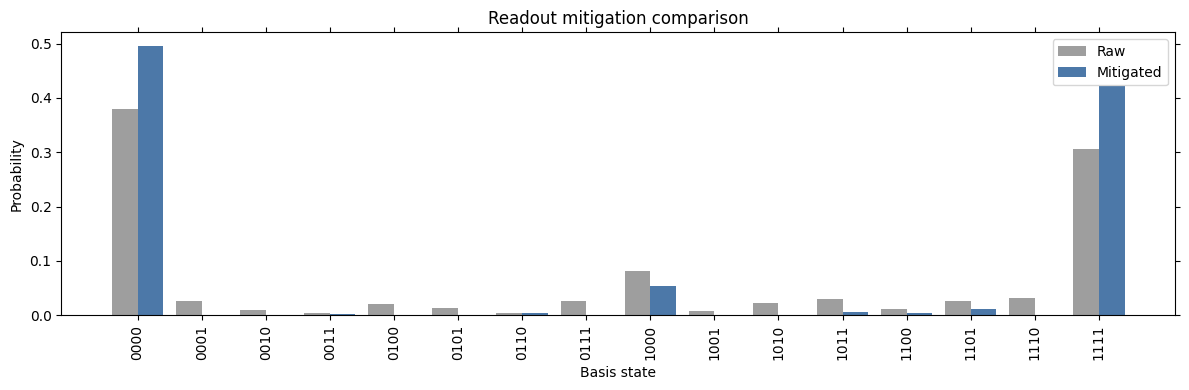

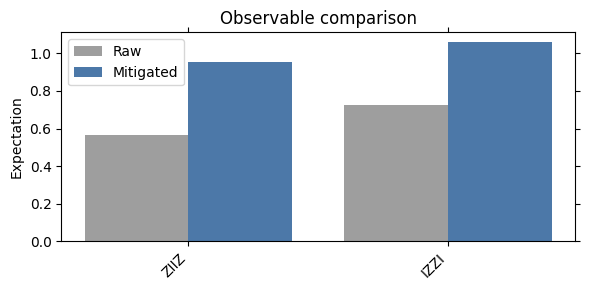

In [5]:
section("plotting")
if result_mitigated.probabilities_raw and result_mitigated.probabilities:
    plot_probabilities_compare(
        result_mitigated.probabilities_raw,
        result_mitigated.probabilities,
        num_qubits,
    )

if result_mitigated.observable_values_raw and result_mitigated.observable_values:
    plot_observables_compare(
        result_mitigated.observable_values_raw,
        result_mitigated.observable_values,
        ["ZIIZ", "IZZI"],
    )

## 6) 下一步建议

你可以继续：
1. 将 `circuit_to_run` 切换为 `circuit_builtin_qft` 或 `circuit_custom`，对比结果差异。
2. 补充硬件信息探索：`from quantum_hw.api.backend import get_chip_info, rank_chips`。
3. 进一步尝试算法教程：`run_shadow` / `run_vqe` / `run_qaoa`。